# **Table of Contents**
In this tutorial, we will go over the following:

0. **PyHealth datasets are not tasks.**
1.   **Using an existing dataset (MIMIC3) to explore data efficiently**
2.   **How data (events) is pre-loaded in PyHealth**
3.   **Deep dive on how to implement and contribute your own PyHealth dataset**




## **PyHealth datasets are not the same thing as tasks**
Before we start, we need to conceptualize how pyhealth.datasets work within the wider framework. Specifically, there's commonly a **misconception where people try to contribute dataset code that are more suitable for [pyhealth.tasks](https://github.com/sunlabuiuc/PyHealth/blob/master/pyhealth/tasks/base_task.py)**. While this might be functionally equivalent in some cases, it's not always true.

![Image description](https://drive.google.com/uc?export=view&id=1hHJcavXqisH9JEMqEVtE4TqEg_E489l5)

For instance, in PyHealth and in general, MIMIC3/4 will often have a variety of tasks that are based on the same dataset (i.e mortality prediction, readmission prediction, medical coding, etc.)

While other datasets were originally intended to serve one purpose like SHHS serving the purpose of sleep staging classification, **many datasets serve as more of a pool of data than an annotated benchmark.** The pyhealth.datasets serves to make preprocessing this pool of data easier and more reproducible for the wider-community.


**For contributors**: This means that any dataset contribution has to be something that isn't already implemented in PyHealth (i.e MIMIC3/MIMIC4, etc.). So, if you're trying to do synthetic data generation with MIMIC3, please see the pyhealth.tasks [tutorial](https://colab.research.google.com/drive/1kKkkBVS_GclHoYTbnOtjyYnSee79hsyT?usp=sharing) instead of implementing your own synthetic data generation dataset.

### Installation Procedure: To be changed to a pip install when a stable version is released.

In [ ]:
!pip install pyhealth

## **Exploring [pyhealth.datasets](https://pyhealth.readthedocs.io/en/latest/api/datasets.html) (e.g., MIMIC-III, COVID19CXR)**
- **[README]**: The PyHealth dataset module is used to process the unstructured raw data into a structured dataset object. Here, we showcase how pyhealth datasets work (i.e how to work with the BaseDataset class) and how it simplifies much of the heavy lifting in doing experimental research while being minimally invasive.
- **[Arguments]**:
  - `root` is the arguments directing to the data folder, e.g., "mimiciii/1.4/".
  - `tables` is a list of table names from raw databases, which specifies the information that will be used in building your dataset.
  - ``dev``: whether to enable dev mode (only use a small subset of the data)
  Default is False.

- **[Functionality]**: currently, we provide the api for:
  - [MIMIC3Dataset](https://pyhealth.readthedocs.io/en/latest/api/datasets/pyhealth.datasets.MIMIC3Dataset.html)
  - [MIMIC4Dataset](https://pyhealth.readthedocs.io/en/latest/api/datasets/pyhealth.datasets.MIMIC4Dataset.html)
  - [eICUDataset](https://pyhealth.readthedocs.io/en/latest/api/datasets/pyhealth.datasets.eICUDataset.html)
  - [OMOPDataset](https://pyhealth.readthedocs.io/en/latest/api/datasets/pyhealth.datasets.OMOPDataset.html): any OMOP-CDM based databases.

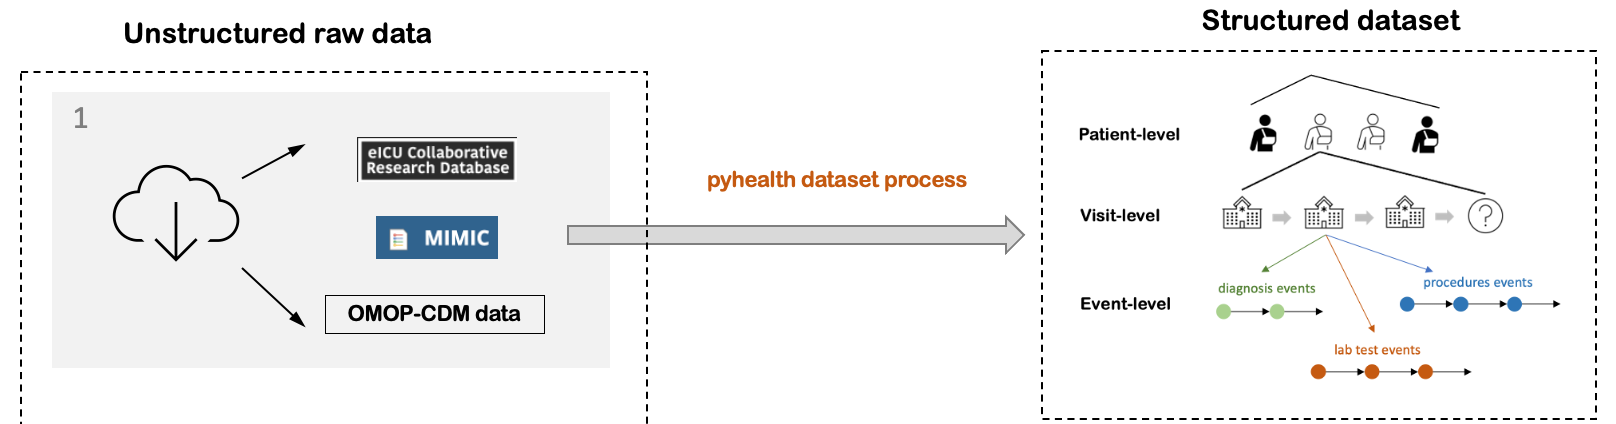

### **Example 1: MIMIC-III**
- **[Initialize]:** In this example, we load the MIMIC-III data by [pyhealth.datasets.MIMIC3Dataset](https://pyhealth.readthedocs.io/en/latest/api/datasets/pyhealth.datasets.MIMIC3Dataset.html).

  - The root of this datasets is in (we use a synthetic MIMIC-III for demo)
    - `https://storage.googleapis.com/pyhealth/Synthetic_MIMIC-III/`.
  - For each patient's ICU stay, user wants to obtain the `DIAGNOSES_ICD`, and `PROCEDURES_ICD` tables. **Note that, different databases have different raw table names**.



In [ ]:
from pyhealth.datasets import MIMIC3Dataset
dataset = MIMIC3Dataset(
    root="https://storage.googleapis.com/pyhealth/Synthetic_MIMIC-III",
    tables=["diagnoses_icd", "procedures_icd", "prescriptions", "noteevents"]
)

No config path provided, using default config


INFO:pyhealth.datasets.mimic3:No config path provided, using default config


Initializing mimic3 dataset from https://storage.googleapis.com/pyhealth/Synthetic_MIMIC-III (dev mode: False)


/usr/local/lib/python3.12/dist-packages/pyhealth/datasets/mimic3.py:50: UserWarning: Events from prescriptions table only have date timestamp (no specific time). This may affect temporal ordering of events.
  warnings.warn(
INFO:pyhealth.datasets.base_dataset:Initializing mimic3 dataset from https://storage.googleapis.com/pyhealth/Synthetic_MIMIC-III (dev mode: False)


- **[Output]:** user can check the data loaded by the `.stats()` function. The output `dataset` effectively contains a table of patients, each containing a set of events, defined by the loaded tables.

In [ ]:
dataset.stats()

No cache_dir provided. Using default cache dir: /root/.cache/pyhealth/3b3dd072-c3a0-53d4-90cd-e62cb8e1294a


INFO:pyhealth.datasets.base_dataset:No cache_dir provided. Using default cache dir: /root/.cache/pyhealth/3b3dd072-c3a0-53d4-90cd-e62cb8e1294a


Scanning table: patients from https://storage.googleapis.com/pyhealth/Synthetic_MIMIC-III/PATIENTS.csv.gz


INFO:pyhealth.datasets.base_dataset:Scanning table: patients from https://storage.googleapis.com/pyhealth/Synthetic_MIMIC-III/PATIENTS.csv.gz


INFO:pyhealth.datasets.base_dataset:Downloading https://storage.googleapis.com/pyhealth/Synthetic_MIMIC-III/PATIENTS.csv to /root/.cache/pyhealth/3b3dd072-c3a0-53d4-90cd-e62cb8e1294a/tmp/48ffef21-7439-4890-8275-18b800666e37/PATIENTS.csv


...

INFO:pyhealth.datasets.base_dataset:Joining with table: https://storage.googleapis.com/pyhealth/Synthetic_MIMIC-III/ADMISSIONS.csv.gz


INFO:pyhealth.datasets.base_dataset:Downloading https://storage.googleapis.com/pyhealth/Synthetic_MIMIC-III/ADMISSIONS.csv to /root/.cache/pyhealth/3b3dd072-c3a0-53d4-90cd-e62cb8e1294a/tmp/ccb26ae6-3af4-4471-9671-57f3e9549279/ADMISSIONS.csv


Caching event dataframe to /root/.cache/pyhealth/3b3dd072-c3a0-53d4-90cd-e62cb8e1294a/global_event_df.parquet...


INFO:pyhealth.datasets.base_dataset:Caching event dataframe to /root/.cache/pyhealth/3b3dd072-c3a0-53d4-90cd-e62cb8e1294a/global_event_df.parquet...


Dataset: mimic3
Dev mode: False
Number of patients: 49993
Number of events: 2176707


In [ ]:
patient1 = dataset.get_patient('1')
patient1

Found 49993 unique patient IDs


INFO:pyhealth.datasets.base_dataset:Found 49993 unique patient IDs


### **We can get a patient's events by calling the .get_patient() function with their get_events()**

**One key thing to understand is that:**



1.   All events are loaded directly from the tables defined above.
2.   Everything is lazily loaded, meaning no computation is done until data access is required.
3.  The events available are all defined in the .yaml file. **We'll go into the inner-workings of how datasets work later in the deep dive section below.**


![Image description](https://drive.google.com/uc?export=view&id=1h3Ija0CqcEBH5ui0upRqRo6Ym1Zt_mTT)




In [ ]:
dataset.get_patient('1').get_events()

[Event(event_type='patients', timestamp=datetime.datetime(2026, 2, 20, 18, 7, 0, 445569), attr_dict={'gender': 'M', 'dob': '2102-09-07', 'dod': None, 'dod_hosp': None, 'dod_ssn': None, 'expire_flag': '0'}),
 Event(event_type='noteevents', timestamp=datetime.datetime(2024, 12, 2, 0, 0), attr_dict={'hadm_id': '100000', 'text': '**Discharge Summary**\n\n**Patient Information:**\n- Name: John Doe\n- Age: 60\n- Gender: Male\n- Medical Record Number: 123456\n\n**Admission Details:**\n- Admit Date: 03/15/2023\n- Admit Time: 14:30\n- Discharge Date: 03/22/2023\n\n**Chief Complaint:**\nShortness of breath and mild chest pain after a spinal manipulation therapy session.\n\n**History of Present Illness:**\nPatient Mr. John Doe, a 60-year-old male with a past medical history significant for Type 2 diabetes mellitus, uncontrolled, with background diabetic retinopathy, secondary malignant neoplasm, transplanted kidney, and a history of drug abuse in remission, presented to the ED with acute onset of

### If you want to iterate across each patient's events, you can do something like below



In [ ]:
patient_ids = dataset.unique_patient_ids
for patient_id in patient_ids[:2]: # Iterate through the first 2 patient IDs
    patient = dataset.get_patient(patient_id)
    print(f"Patient ID: {patient_id}")
    for i, event in enumerate(patient.get_events()):
        if i < 2:  # Print only the first 2 events for each patient
            print(event)
        else:
            break # Stop iterating through events after printing 2

Patient ID: 17900
Event(event_type='patients', timestamp=datetime.datetime(2026, 2, 20, 18, 7, 0, 461446), attr_dict={'gender': 'M', 'dob': '2125-04-11', 'dod': None, 'dod_hosp': None, 'dod_ssn': None, 'expire_flag': '0'})
Event(event_type='prescriptions', timestamp=datetime.datetime(2125, 6, 22, 0, 0), attr_dict={'hadm_id': '118575', 'drug': 'Gentamicin', 'drug_type': 'MAIN', 'drug_name_poe': None, 'drug_name_generic': None, 'formulary_drug_cd': 'GENT80PM', 'gsn': '009291', 'ndc': '00338050941', 'prod_strength': '80mg Premix', 'dose_val_rx': '80', 'dose_unit_rx': 'mg', 'form_val_disp': '1', 'form_unit_disp': 'BAG', 'route': 'IV', 'enddate': '2125-06-23'})
Patient ID: 23726
Event(event_type='patients', timestamp=datetime.datetime(2026, 2, 20, 18, 7, 0, 472646), attr_dict={'gender': 'F', 'dob': '1976-07-10', 'dod': '1976-11-10', 'dod_hosp': '1976-11-10', 'dod_ssn': '1976-11-10', 'expire_flag': '1'})
Event(event_type='icustays', timestamp=datetime.datetime(1976, 11, 10, 0, 0), attr_dict=

### Let us do some explorations with the events



In [ ]:
# get patient dictionary
icd_events = dataset.get_patient('1').get_events("diagnoses_icd")
print(icd_events)
for icd_event in icd_events:
    print(icd_event.icd9_code)

[Event(event_type='diagnoses_icd', timestamp=datetime.datetime(2103, 6, 7, 12, 0), attr_dict={'hadm_id': '100000', 'icd9_code': '86121', 'seq_num': '0'}), Event(event_type='diagnoses_icd', timestamp=datetime.datetime(2103, 6, 7, 12, 0), attr_dict={'hadm_id': '100000', 'icd9_code': 'V4589', 'seq_num': '1'}), Event(event_type='diagnoses_icd', timestamp=datetime.datetime(2103, 6, 7, 12, 0), attr_dict={'hadm_id': '100000', 'icd9_code': '25082', 'seq_num': '2'}), Event(event_type='diagnoses_icd', timestamp=datetime.datetime(2103, 6, 7, 12, 0), attr_dict={'hadm_id': '100000', 'icd9_code': '79902', 'seq_num': '3'}), Event(event_type='diagnoses_icd', timestamp=datetime.datetime(2103, 6, 7, 12, 0), attr_dict={'hadm_id': '100000', 'icd9_code': '19889', 'seq_num': '4'}), Event(event_type='diagnoses_icd', timestamp=datetime.datetime(2103, 6, 7, 12, 0), attr_dict={'hadm_id': '100000', 'icd9_code': '36201', 'seq_num': '5'}), Event(event_type='diagnoses_icd', timestamp=datetime.datetime(2103, 6, 7, 1

In [ ]:
# get patient dictionary
icd_events = dataset.get_patient('1').get_events("procedures_icd")
print(icd_events)
for icd_event in icd_events:
    print(icd_event.icd9_code)

[Event(event_type='procedures_icd', timestamp=datetime.datetime(2103, 6, 7, 12, 0), attr_dict={'hadm_id': '100000', 'icd9_code': '8472', 'seq_num': '3'}), Event(event_type='procedures_icd', timestamp=datetime.datetime(2103, 6, 7, 12, 0), attr_dict={'hadm_id': '100000', 'icd9_code': '544', 'seq_num': '1'}), Event(event_type='procedures_icd', timestamp=datetime.datetime(2103, 6, 7, 12, 0), attr_dict={'hadm_id': '100000', 'icd9_code': '3895', 'seq_num': '0'}), Event(event_type='procedures_icd', timestamp=datetime.datetime(2103, 6, 7, 12, 0), attr_dict={'hadm_id': '100000', 'icd9_code': '9618', 'seq_num': '2'})]
8472
544
3895
9618


**And, if we wanted to pick an event at specific interval (i.e a hospital visit/admission), we can:**

In [ ]:
admissions = dataset.get_patient('1').get_events("admissions")
start = admissions[0].timestamp
procedures = dataset.get_patient('1').get_events("procedures_icd", start=start)
print(procedures)


[Event(event_type='procedures_icd', timestamp=datetime.datetime(2103, 6, 7, 12, 0), attr_dict={'hadm_id': '100000', 'icd9_code': '8472', 'seq_num': '3'}), Event(event_type='procedures_icd', timestamp=datetime.datetime(2103, 6, 7, 12, 0), attr_dict={'hadm_id': '100000', 'icd9_code': '544', 'seq_num': '1'}), Event(event_type='procedures_icd', timestamp=datetime.datetime(2103, 6, 7, 12, 0), attr_dict={'hadm_id': '100000', 'icd9_code': '3895', 'seq_num': '0'}), Event(event_type='procedures_icd', timestamp=datetime.datetime(2103, 6, 7, 12, 0), attr_dict={'hadm_id': '100000', 'icd9_code': '9618', 'seq_num': '2'})]


## **Going Deeper: What event types and attributes are available?**

Below, we showcase an example of our config YAML files that pre-define what is pre-loaded for use in MIMIC3. For a full look of the config file as well as where this is located in PyHealth, see [here](https://github.com/sunlabuiuc/PyHealth/blob/master/pyhealth/datasets/configs/mimic3.yaml). For brevity's sake, we showcase the tables we used above below:





```
version: "1.4"
tables:
  patients:
    file_path: "PATIENTS.csv.gz"
    patient_id: "subject_id"
    timestamp: null
    attributes:
    - "gender"
    - "dob"
    - "dod"
    - "dod_hosp"
    - "dod_ssn"
    - "expire_flag"

  admissions:
    file_path: "ADMISSIONS.csv.gz"
    patient_id: "subject_id"
    timestamp: "admittime"
    attributes:
      - "hadm_id"
      - "admission_type"
      - "admission_location"
      - "insurance"
      - "language"
      - "religion"
      - "marital_status"
      - "ethnicity"
      - "edregtime"
      - "edouttime"
      - "diagnosis"
      - "discharge_location"
      - "dischtime"
      - "hospital_expire_flag"

  diagnoses_icd:
    file_path: "DIAGNOSES_ICD.csv.gz"
    patient_id: "subject_id"
    join:
      - file_path: "ADMISSIONS.csv.gz"
        "on": "hadm_id"
        how: "inner"
        columns:
          - "dischtime"
    timestamp: "dischtime"
    attributes:
      - "icd9_code"
      - "seq_num"

  procedures_icd:
    file_path: "PROCEDURES_ICD.csv.gz"
    patient_id: "subject_id"
    join:
      - file_path: "ADMISSIONS.csv.gz"
        "on": "hadm_id"
        how: "inner"
        columns:
          - "dischtime"
    timestamp: "dischtime"
    attributes:
      - "icd9_code"
      - "seq_num"

```



One key thing you'll notice is the name of the **tables** that are available in the loading of our dataset. In this case, **"diagnoses_icd"** and **"procedures_icd"** are defined with the following required definitions in the YAML file above:





*   **patient_id**, uses to define which column "subject_id" that represents the identifier for the patient_ids. Effectively, this defines what a "sample" is in our dataset. Left null, it indicates that every row in each "table" (file.csv, etc.) is a sample in our dataframe.

*  **file_path**, defines what file in the **root* directory that should be read by PyHealth's polar backend to load the data from.

* **timestamp**, defines what table column to look at for time parsing

* **attributes**, defines what columns to read for each row to store in our Event data structure. In this case, for each table,  we can see we have **icd9_code** that we explored above.

* **join**, we can also optionally define joins if we want to merge tables into the main **ADMISSIONS** tables based on their hospital admissions id **hadm_id** for task-specific purposes (i.e mortality prediction/readmission prediction/etc. We discuss more of this in a later tutorial).

## **Contributing your own dataset**
We go over how to define your own datasets below. There are essentially 2 steps:


1.   Defining your dataset_config.yaml file.
2.   Defining your dataset_interface.py

We go over two implementation examples to showcase how to implement **2 types of datasets.**

1. Datasets that are already in a table (i.e MIMIC-III)
2. Datasets that are in a file directory format (i.e Covid19CXR)


### **Example 1 - MIMIC3**

#### **1. Defining mimic3.yaml**

Every configuration file is defined in **pyhealth/datasets/configs** [here](https://github.com/sunlabuiuc/PyHealth/tree/master/pyhealth/datasets/configs).

Simply create a .yaml file, and define the **tables** that are available like the following:



```
version: "1.4"
tables:
  patients:
    file_path: "PATIENTS.csv.gz"
    patient_id: "subject_id"
    timestamp: null
    attributes:
    - "gender"
    - "dob"
    - "dod"
    - "dod_hosp"
    - "dod_ssn"
    - "expire_flag"
```
The PyHealth BaseDataset class will automatically read these tables in with these defined attributes.



#### **2. Defining MIMIC3Dataset**
Once your config.yaml file is defined, we will need to define a class that inherits **BaseDataset**, which does much of the processing underneath the hood. For the ugly details, see [here](https://github.com/sunlabuiuc/PyHealth/blob/master/pyhealth/datasets/base_dataset.py).



In [ ]:
import logging
import warnings
from pathlib import Path
from typing import List, Optional

import polars as pl

from pyhealth.datasets.base_dataset import BaseDataset

logger = logging.getLogger(__name__)


class MIMIC3Dataset(BaseDataset):
    """
    A dataset class for handling MIMIC-III data.

    This class is responsible for loading and managing the MIMIC-III dataset,
    which includes tables such as patients, admissions, and icustays.

    Attributes:
        root (str): The root directory where the dataset is stored.
        tables (List[str]): A list of tables to be included in the dataset.
        dataset_name (Optional[str]): The name of the dataset.
        config_path (Optional[str]): The path to the configuration file.
    """

    def __init__(
        self,
        root: str,
        tables: List[str],
        dataset_name: Optional[str] = None,
        config_path: Optional[str] = None,
        **kwargs
    ) -> None:
        """
        Initializes the MIMIC4Dataset with the specified parameters.

        Args:
            root (str): The root directory where the dataset is stored.
            tables (List[str]): A list of additional tables to include.
            dataset_name (Optional[str]): The name of the dataset. Defaults to "mimic3".
            config_path (Optional[str]): The path to the configuration file. If not provided, a default config is used.
        """
        if config_path is None:
            logger.info("No config path provided, using default config")
            config_path = Path(__file__).parent / "configs" / "mimic3.yaml"
        default_tables = ["patients", "admissions", "icustays"]
        tables = default_tables + tables
        if "prescriptions" in tables:
            warnings.warn(
                "Events from prescriptions table only have date timestamp (no specific time). "
                "This may affect temporal ordering of events.",
                UserWarning,
            )
        super().__init__(
            root=root,
            tables=tables,
            dataset_name=dataset_name or "mimic3",
            config_path=config_path,
            **kwargs
        )
        return

    def preprocess_noteevents(self, df: pl.LazyFrame) -> pl.LazyFrame:
        """
        Table-specific preprocess function which will be called by BaseDataset.load_table().

        Preprocesses the noteevents table by ensuring that the charttime column
        is populated. If charttime is null, it uses chartdate with a default
        time of 00:00:00.

        See: https://mimic.mit.edu/docs/iii/tables/noteevents/#chartdate-charttime-storetime.

        Args:
            df (pl.LazyFrame): The input dataframe containing noteevents data.

        Returns:
            pl.LazyFrame: The processed dataframe with updated charttime
            values.
        """
        df = df.with_columns(
            pl.when(pl.col("charttime").is_null())
            .then(pl.col("chartdate") + pl.lit(" 00:00:00"))
            .otherwise(pl.col("charttime"))
            .alias("charttime")
        )
        return df

#### **Code Breakdown**
It looks scary at first, but let's break it down, we can first specify a default config path that **BaseDataset** will use to load tables:

```
if config_path is None:
            logger.info("No config path provided, using default config")
            config_path = Path(__file__).parent / "configs" / "mimic3.yaml"
```
Next, we define some defualt tables that are always parsed for the dataset, regardless of the user's arguments. **This is key for datasets where there is one metadata table that unifies all other tables like it is in MIMIC-III.** We also offer some warnings about dataset specifics for those who have never used the prescriptions table before.


```
default_tables = ["patients", "admissions", "icustays"]
        tables = default_tables + tables
        if "prescriptions" in tables:
            warnings.warn(
                "Events from prescriptions table only have date timestamp (no specific time). "
                "This may affect temporal ordering of events.",
                UserWarning,
            )
```

Finally, **we make sure to run the optimized BaseDataset:** that will do the heavy lifting behind the scenes.

```
super().__init__(
            root=root,
            tables=tables,
            dataset_name=dataset_name or "mimic3",
            config_path=config_path,
            **kwargs
        )
        return
```


**You'll also see we offer overrides for how tables are processed in BaseDataset:**

```
def preprocess_noteevents(self, df: pl.LazyFrame) -> pl.LazyFrame:
        """
        Table-specific preprocess function which will be called by BaseDataset.load_table().
    
        Preprocesses the noteevents table by ensuring that the charttime column
        is populated. If charttime is null, it uses chartdate with a default
        time of 00:00:00.

        See: https://mimic.mit.edu/docs/iii/tables/noteevents/#chartdate-charttime-storetime.

        Args:
            df (pl.LazyFrame): The input dataframe containing noteevents data.

        Returns:
            pl.LazyFrame: The processed dataframe with updated charttime
            values.
        """
        df = df.with_columns(
            pl.when(pl.col("charttime").is_null())
            .then(pl.col("chartdate") + pl.lit(" 00:00:00"))
            .otherwise(pl.col("charttime"))
            .alias("charttime")
        )
        return df
```

BaseDataset will override how it reads any **table** if you define your own **preprocess_{table}** functions within the class. Here, it adjusts for how dates are represented in the noteevents table, which is different than the usual discharge date columns within the other tables.





### **Example 2. COVID-CXR Dataset**
Here, the data is not formatted as a table, so you might be confused on how to contribute a dataset.

**If none of the data is defined in a tabular format, we can simply construct a table such that it can leverage all of the tricks implemented by BaseDataset.**

Let's first start by defining our dataset implementation, located [here](https://github.com/sunlabuiuc/PyHealth/blob/master/pyhealth/datasets/covid19_cxr.py).

#### **1. Defining COVID19CXRDataset**

In [ ]:
import logging
import os
from pathlib import Path
from typing import Optional

import pandas as pd

from pyhealth.tasks import COVID19CXRClassification
from pyhealth.datasets.base_dataset import BaseDataset

logger = logging.getLogger(__name__)


class COVID19CXRDataset(BaseDataset):
    """Base image dataset for COVID-19 Radiography Database.

    Dataset is available at:
    https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database

    Data Sources:
    ------------
    COVID-19 data:
        - 2473 CXR images from padchest dataset[1]
        - 183 CXR images from a Germany medical school[2]
        - 559 CXR images from SIRM, Github, Kaggle & Tweeter[3,4,5,6]
        - 400 CXR images from another Github source[7]

    Normal images:
        - 8851 from RSNA [8]
        - 1341 from Kaggle [9]

    Lung opacity images:
        - 6012 from Radiological Society of North America (RSNA) CXR dataset[8]

    Viral Pneumonia images:
        - 1345 from the Chest X-Ray Images (pneumonia) database[9]

    Citations:
    ---------
    If you use this dataset, please cite:
    1. M.E.H. Chowdhury, T. Rahman, A. Khandakar, et al. "Can AI help in
       screening Viral and COVID-19 pneumonia?" IEEE Access, Vol. 8, 2020,
       pp. 132665-132676.
    2. Rahman, T., Khandakar, A., Qiblawey, Y., et al. "Exploring the Effect
       of Image Enhancement Techniques on COVID-19 Detection using Chest X-ray
       Images." arXiv preprint arXiv:2012.02238.

    References:
    ----------
    [1] https://bimcv.cipf.es/bimcv-projects/bimcv-covid19/
    [2] https://github.com/ml-workgroup/covid-19-image-repository/tree/master/png
    [3] https://sirm.org/category/senza-categoria/covid-19/
    [4] https://eurorad.org
    [5] https://github.com/ieee8023/covid-chestxray-dataset
    [6] https://figshare.com/articles/COVID-19_Chest_X-Ray_Image_Repository/12580328
    [7] https://github.com/armiro/COVID-CXNet
    [8] https://www.kaggle.com/c/rsna-pneumonia-detection-challenge/data
    [9] https://www.kaggle.com/paultimothymooney/chest-xray-pneumonia

    Args:
        root: Root directory of the raw data containing the dataset files.
        dataset_name: Optional name of the dataset. Defaults to "covid19_cxr".
        config_path: Optional path to the configuration file. If not provided,
            uses the default config in the configs directory.

    Attributes:
        root: Root directory of the raw data.
        dataset_name: Name of the dataset.
        config_path: Path to the configuration file.

    Examples:
        >>> from pyhealth.datasets import COVID19CXRDataset
        >>> dataset = COVID19CXRDataset(
        ...     root="/path/to/covid19_cxr"
        ... )
        >>> dataset.stats()
        >>> samples = dataset.set_task()
        >>> print(samples[0])
    """

    def __init__(
        self,
        root: str,
        dataset_name: Optional[str] = None,
        config_path: Optional[str] = None,
    ) -> None:
        if config_path is None:
            logger.info("No config path provided, using default config")
            config_path = (
                Path(__file__).parent / "configs" / "covid19_cxr.yaml"
            )
        if not os.path.exists(os.path.join(root, "covid19_cxr-metadata-pyhealth.csv")):
            self.prepare_metadata(root)
        default_tables = ["covid19_cxr"]
        super().__init__(
            root=root,
            tables=default_tables,
            dataset_name=dataset_name or "covid19_cxr",
            config_path=config_path,
        )
        return

    def prepare_metadata(self, root: str) -> None:
        """Prepare metadata for the COVID-19 CXR dataset.

        Args:
            root: Root directory containing the dataset files.

        This method:
        1. Reads metadata from Excel files for each class
        2. Processes file paths and labels
        3. Combines all data into a single DataFrame
        4. Saves the processed metadata to a CSV file
        """
        # process and merge raw xlsx files from the dataset
        covid = pd.DataFrame(
            pd.read_excel(f"{root}/COVID.metadata.xlsx")
        )
        covid["FILE NAME"] = covid["FILE NAME"].apply(
            lambda x: f"{root}/COVID/images/{x}.png"
        )
        covid["label"] = "COVID"
        lung_opacity = pd.DataFrame(
            pd.read_excel(f"{root}/Lung_Opacity.metadata.xlsx")
        )
        lung_opacity["FILE NAME"] = lung_opacity["FILE NAME"].apply(
            lambda x: f"{root}/Lung_Opacity/images/{x}.png"
        )
        lung_opacity["label"] = "Lung Opacity"
        normal = pd.DataFrame(
            pd.read_excel(f"{root}/Normal.metadata.xlsx")
        )
        normal["FILE NAME"] = normal["FILE NAME"].apply(
            lambda x: x.capitalize()
        )
        normal["FILE NAME"] = normal["FILE NAME"].apply(
            lambda x: f"{root}/Normal/images/{x}.png"
        )
        normal["label"] = "Normal"
        viral_pneumonia = pd.DataFrame(
            pd.read_excel(f"{root}/Viral Pneumonia.metadata.xlsx")
        )
        viral_pneumonia["FILE NAME"] = viral_pneumonia["FILE NAME"].apply(
            lambda x: f"{root}/Viral Pneumonia/images/{x}.png"
        )
        viral_pneumonia["label"] = "Viral Pneumonia"
        df = pd.concat(
            [covid, lung_opacity, normal, viral_pneumonia],
            axis=0,
            ignore_index=True
        )
        df = df.drop(columns=["FORMAT", "SIZE"])
        df.columns = ["path", "url", "label"]
        for path in df.path:
            assert os.path.isfile(path), f"File {path} does not exist"
        df.to_csv(
            os.path.join(root, "covid19_cxr-metadata-pyhealth.csv"),
            index=False
        )
        return

    @property
    def default_task(self) -> COVID19CXRClassification:
        """Returns the default task for this dataset.

        Returns:
            COVID19CXRClassification: The default classification task.
        """
        return COVID19CXRClassification()

#### Code Breakdown
Taking a closer look, the init() function is practically the same as our MIMIC3 implementation. But, the one difference is we have a **prepare_metadata()** function that constructs a metadata to be used for our BaseDataset. Looking closer at this function, we can see that:

1. **Reading Excel metadata files**: The function reads four separate Excel files containing metadata for each disease category:
   ```python
   covid = pd.DataFrame(pd.read_excel(f"{root}/COVID.metadata.xlsx"))
   lung_opacity = pd.DataFrame(pd.read_excel(f"{root}/Lung_Opacity.metadata.xlsx"))
   normal = pd.DataFrame(pd.read_excel(f"{root}/Normal.metadata.xlsx"))
   viral_pneumonia = pd.DataFrame(pd.read_excel(f"{root}/Viral Pneumonia.metadata.xlsx"))
   ```

2. **Constructing file paths**: For each category, it builds the complete file paths by taking the filename from the Excel metadata and prepending the appropriate directory path:
   ```python
   covid["FILE NAME"] = covid["FILE NAME"].apply(
       lambda x: f"{root}/COVID/images/{x}.png"
   )
   lung_opacity["FILE NAME"] = lung_opacity["FILE NAME"].apply(
       lambda x: f"{root}/Lung_Opacity/images/{x}.png"
   )
   # Special handling for Normal images with capitalization
   normal["FILE NAME"] = normal["FILE NAME"].apply(lambda x: x.capitalize())
   normal["FILE NAME"] = normal["FILE NAME"].apply(
       lambda x: f"{root}/Normal/images/{x}.png"
   )
   ```

3. **Adding labels**: Each DataFrame gets a "label" column with the corresponding disease category:
   ```python
   covid["label"] = "COVID"
   lung_opacity["label"] = "Lung Opacity"
   normal["label"] = "Normal"
   viral_pneumonia["label"] = "Viral Pneumonia"
   ```

4. **Combining and cleaning**: All four DataFrames are concatenated into a single DataFrame, and unnecessary columns are dropped:
   ```python
   df = pd.concat([covid, lung_opacity, normal, viral_pneumonia], axis=0, ignore_index=True)
   df = df.drop(columns=["FORMAT", "SIZE"])
   ```

5. **Renaming columns**: The final DataFrame columns are standardized to match the expected schema (below):
   ```python
   df.columns = ["path", "url", "label"]
   ```

6. **Validation**: The function verifies that all image files actually exist on disk:
   ```python
   for path in df.path:
       assert os.path.isfile(path), f"File {path} does not exist"
   ```

7. **Saving processed metadata**: The combined and cleaned metadata is saved as a CSV file:
   ```python
   df.to_csv(os.path.join(root, "covid19_cxr-metadata-pyhealth.csv"), index=False)
   ```

This preprocessing step transforms the original dataset's scattered Excel metadata files into a single, standardized CSV file that the BaseDataset can easily consume according to the YAML configuration.

#### **2. Defining covid19_cxr.yaml**
Once you essentially define your own metadata table, we can define a config.yaml file that takes all of these into account such that we can easily access all of the images in our Events() format.



```
version: "5.0"
tables:
  covid19_cxr:
    file_path: "covid19_cxr-metadata-pyhealth.csv"
    patient_id: null
    timestamp: null
    attributes:
    - "path"
    - "url"
    - "label"
  ```

You'll see the typical **tables** and other necessary definitions. Taking a closer look at the **attributes:**, we can see 3 key columns that we've created from earlier **path**, **url**, **label** that characterize each X-ray.

These attributes are now directly explorable by any user using the Event.path or Event.url notation from earlier.

If you find it useful, please give us a star ⭐ (fork, and watch) at https://github.com/sunlabuiuc/PyHealth.

Thanks very much for your support!